In [33]:
!pip install spectral

In [34]:
import os
import time
import warnings
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import seaborn as sns
import spectral
import spectral.io.envi as envi
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
                             cohen_kappa_score, confusion_matrix)
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras.layers import (Conv3D, Dense, Dropout, Flatten, Input, concatenate, Reshape)
from tensorflow.keras import regularizers
from tensorflow.keras import layers, Model
from keras.losses import categorical_crossentropy
from keras.models import Model, Sequential
from tensorflow.keras.layers import (Activation, Lambda, multiply)
from tensorflow.keras.optimizers import Adam
from keras.optimizers import Adam
from tensorflow.keras.optimizers import legacy
from operator import truediv
from keras.utils import to_categorical
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load HSI Datasets**

In [35]:
## Loading Datasets
def LoadHSIData(method):
    data_path = '/content/drive/MyDrive/HSI/'
    print(data_path);
    if method == 'PU':
        HSI = sio.loadmat(os.path.join(data_path, 'PaviaU.mat'))['paviaU']
        GT = sio.loadmat(os.path.join(data_path, 'PaviaU_gt.mat'))['paviaU_gt']
        Num_Classes = 9
        target_names = ['Asphalt','Meadows','Gravel','Trees', 'Painted','Soil','Bitumen',
                        'Bricks','Shadows']
    elif method == 'SA':
        HSI = sio.loadmat(os.path.join(data_path, 'Salinas_corrected.mat'))['salinas_corrected']
        GT = sio.loadmat(os.path.join(data_path, 'Salinas_gt.mat'))['salinas_gt']
        Num_Classes = 16
        target_names = ['Weeds_1','Weeds_2','Fallow',
                        'Fallow_rough_plow','Fallow_smooth', 'Stubble','Celery',
                        'Grapes_untrained','Soil_vinyard_develop','Corn_Weeds',
                        'Lettuce_4wk','Lettuce_5wk','Lettuce_6wk',
                        'Lettuce_7wk', 'Vinyard_untrained','Vinyard_trellis']
    elif method == 'UH':
      HSI = sio.loadmat(os.path.join(data_path, 'Houston.mat'))['Houston']
      GT = sio.loadmat(os.path.join(data_path, 'Houston_GT.mat'))['Houston_GT']

      Num_Classes = 15
      target_names = ['Healthy grass', 'Stressed grass', 'Synthetic grass', 'Trees',
                    'Soil', 'Water', 'Residential', 'Commercial', 'Road',
                    'Highway', 'Railway', 'Parking Lot 1', 'Parking Lot 2',
                    'Tennis Court', 'Running Track']
    return HSI, GT, Num_Classes, target_names

**Important Internal Functions**

In [36]:
## Prediction Model
def PreModel(Actual, model):
  ## Validation Prediction Model
  prediction = model.predict(Actual)
  argmax_prediction = np.argmax(prediction, axis=1) + 1  # Add 1 to the argmax result to shift the class labels
  non_zero_classes = np.unique(argmax_prediction)  # Get the unique non-zero class labels
  # Remove the 0 class label if it exists in the non_zero_classes array
  if 0 in non_zero_classes:
    non_zero_classes = non_zero_classes[non_zero_classes != 0]
  # Filter out the non-zero classes from the argmax_prediction array
  Pre = argmax_prediction[np.isin(argmax_prediction, non_zero_classes)]
  return Pre


def Tranform_Labels(test_matrix, TeInd, Te_Pre):
    """
    Reconstruct predicted labels into original image shape
    """

    # Create empty label image
    labels = np.zeros((test_matrix.shape[0], test_matrix.shape[1]))

    # If predictions are one-hot encoded, convert to class index
    if len(Te_Pre.shape) > 1:
        Te_Pre = np.argmax(Te_Pre, axis=1)

    # Fill predicted labels into correct pixel locations
    for i, index in enumerate(TeInd):
        row = index // test_matrix.shape[1]
        col = index % test_matrix.shape[1]
        labels[row, col] = Te_Pre[i]

    return labels





## Computing the Accuracies and Confusion Matrix for Disjoint Samples
def ClassificationReports(TeC, HSID, Te_Pre, target_names):
  classification = classification_report(np.argmax(TeC, axis=1)+1, Te_Pre, target_names = target_names)
  oa = accuracy_score(np.argmax(TeC, axis=1)+1, Te_Pre)
  oa = round(oa, 4)
  confusion = confusion_matrix(np.argmax(TeC, axis=1)+1, Te_Pre)
  list_diag = np.diag(confusion)
  list_raw_sum = np.sum(confusion, axis=1)
  each_acc = np.nan_to_num(truediv(list_diag, list_raw_sum))
  aa = np.mean(each_acc)
  aa = round(aa, 4)
  kappa = cohen_kappa_score(np.argmax(TeC, axis=1)+1, Te_Pre)
  kappa = round(kappa, 4)
  return classification, confusion, oa*100, each_acc*100, aa*100, kappa*100


## Writing Results in CSV files
def CSVResults(file_name, Tr_Time, Te_Time, Te_classification,
               Te_Confusion, Te_Kappa, Te_OA, Te_AA, Te_Per_Class):
    Te_classification = str(Te_classification)
    Te_Confusion = str(Te_Confusion)
    with open(file_name, 'w') as CSV_file:
      CSV_file.write('{} Tr_Time'.format(Tr_Time))
      CSV_file.write('\n')
      CSV_file.write('{} Te_Time'.format(Te_Time))
      CSV_file.write('\n')
      CSV_file.write('{} Te Kappa (%)'.format(Te_Kappa))
      CSV_file.write('\n')
      CSV_file.write('{} Te Overall (%)'.format(Te_OA))
      CSV_file.write('\n')
      CSV_file.write('{} Te Average (%)'.format(Te_AA))
      CSV_file.write('\n')
      CSV_file.write('{} Te Classification'.format(Te_classification))
      CSV_file.write('\n')
      CSV_file.write('{} Te Per Class'.format(Te_Per_Class))
      CSV_file.write('\n')
      CSV_file.write('{} Te Confussion'.format(Te_Confusion))
      CSV_file.write('\n')
    return CSV_file

**Initializating Parameters**

In [37]:
## Global Parameters for Loop
HSID = "PU" ## UH, PU, SA
WS = 8
teRatio = 0.50
vrRatio = 0.50
k = 15
adam = tf.keras.optimizers.Adam(learning_rate= 0.0001, decay = 1e-06)
epochs = 40
batch_size = 56

**Dimensionality Reduction and 3D Patch Process**

In [38]:
## Different Dimensional Reduction Methods
def DLMethod(HSI, NC = 75):
  RHSI = np.reshape(HSI, (-1, HSI.shape[2]))
  pca = PCA(n_components = NC, whiten = True)
  RHSI = pca.fit_transform(RHSI)
  RHSI = np.reshape(RHSI, (HSI.shape[0], HSI.shape[1], NC))
  return RHSI

## Creat Patches for 3D (Spatial-Spectral) Models
def ImageCubes(HSI, GT, WS=WS, removeZeroLabels=True):
    num_rows, num_cols, num_bands = HSI.shape
    margin = int(WS / 2)
    padded_data = np.pad(HSI, ((margin, margin), (margin, margin), (0, 0)), mode='constant')
    image_cubes = np.zeros((num_rows * num_cols, WS, WS, num_bands))
    patchesLabels = np.zeros((num_rows * num_cols))
    patchIndex = 0
    for r in range(margin, num_rows + margin):
        for c in range(margin, num_cols + margin):
            cube = padded_data[r - margin: r + margin, c - margin: c + margin, :]
            image_cubes[patchIndex, :, :, :] = cube
            patchesLabels[patchIndex] = GT[r-margin, c-margin]
            patchIndex = patchIndex + 1
    return image_cubes, patchesLabels

**Preprocessing**

In [39]:
## Main Function to load Datasets, Dimensional Reduction and Creating Patchs for CNN
HSI, GT, Num_Classes, target_names = LoadHSIData(HSID)
## Reduce the Dimensionality
start = time.time()
RDHSI = DLMethod(HSI, NC = k)
end = time.time()
DL_Time = end - start
## Create Image Cubes for Model Building
CRDHSI, CGT = ImageCubes(RDHSI, GT, WS = WS)

/content/drive/MyDrive/HSI/


**Disjoint Train/Validation/Test Sample Selection**

In [40]:
## Set seed for reproducibility
np.random.seed(42)
## Calculate the number of rows for each sample
num_rows, num_cols = GT.shape
## Flatten the matrix into a 1D array
flattened = GT.flatten()
## Get the unique values and their counts, excluding the 0 class
unique_values, value_counts = np.unique(flattened, return_counts=True)
nonzero_indices = np.where(unique_values != 0)[0]
unique_values = unique_values[nonzero_indices]
## Create a DataFrame to store sample counts
Samples = pd.DataFrame(columns=['Training', 'Validation', 'Test'])
## Create lists to store the indices
TrInd = []
VaInd = []
TeInd = []
## Split the data for each class
for value in unique_values:
    class_indices = np.where(flattened == value)[0]
    train_indices, test_indices = train_test_split(class_indices, test_size=teRatio)
    train_indices, val_indices = train_test_split(train_indices, test_size=vrRatio)
    ## Save the sample counts
    Samples.loc[value] = [len(train_indices), len(val_indices), len(test_indices)]
    ## Store the indices
    TrInd.extend(train_indices)
    VaInd.extend(val_indices)
    TeInd.extend(test_indices)

## Convert the DataFrame to a CSV file
file_name = f"{HSID}_{teRatio}_{vrRatio}_{k}_{WS}_Samples.csv"
Samples.to_csv(file_name, index_label='Class')
## Reshape the selected samples back into the GT size
train_matrix = np.zeros_like(GT)
val_matrix = np.zeros_like(GT)
test_matrix = np.zeros_like(GT)
## Convert Train/Validation/Test samples into Matrix
train_matrix.flat[TrInd] = 1
val_matrix.flat[VaInd] = 1
test_matrix.flat[TeInd] = 1
## Select Train/Validation/Test Samples
Tr = CRDHSI[TrInd]
Va = CRDHSI[VaInd]
Te = CRDHSI[TeInd]
## Convert labels into one-hot encoding
TrC = to_categorical(CGT[TrInd] -1)
VaC = to_categorical(CGT[VaInd] -1)
TeC = to_categorical(CGT[TeInd] -1)

In [41]:
# Define the Pyramid 3D CNN model
def pyramid_3d_cnn(WS, k, num_pyramid_levels):
    input_shape = (WS, WS, k, 1)
    max_patch_size = min(input_shape[:3])
    patch_size = max_patch_size
    inputs = layers.Input(shape=input_shape)
    x = inputs
    # Create pyramid levels
    pyramid_outputs = []
    # Create pyramid levels
    for level in range(num_pyramid_levels):
        scale = 2 ** level
        scaled_input_shape = (input_shape[0] // scale, input_shape[1] // scale, input_shape[2] // scale, input_shape[3])
        # Convolutional layers for each pyramid level
        x = tf.keras.layers.Conv3D(32, kernel_size=(1, patch_size, patch_size), activation='relu', padding='same', input_shape=scaled_input_shape)(x)
        x = tf.keras.layers.Conv3D(64, kernel_size=(1, patch_size, patch_size), activation='relu', padding='same')(x)
        pyramid_outputs.append(x)

    # Merge the feature maps from pyramid levels
    merged = tf.keras.layers.concatenate(pyramid_outputs, axis=-1)
    return Model(inputs=inputs, outputs=merged)

def PyFormer(WS, k, num_classes):
    num_layers = 2
    num_heads = 4
    mlp_dim = 64
    num_pyramid_levels = 2
    input_shape = (WS, WS, k, 1)
    inputs = layers.Input(shape=input_shape)
    x = pyramid_3d_cnn(WS, k, num_pyramid_levels)(inputs)
    x = layers.Activation("relu")(x)
    for i in range(num_layers):
        x = layers.LayerNormalization()(x)
        x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=k)(x, x)
        x = layers.Add()([x, inputs])
        y = layers.Conv3D(filters=k, kernel_size=(1, WS, WS), activation='relu', padding='same')(x)
        y = layers.Conv3D(filters=2*mlp_dim, kernel_size=(1, WS, WS), activation='relu', padding='same')(y)
        x = layers.Add()([x, y])
    # Apply regularization
    flatten_layer = layers.Flatten()(x)
    x = layers.Dense(units=128, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01))(flatten_layer)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = Model(inputs=inputs, outputs=outputs, name='PyFormer')
    return model

In [42]:
def train_and_evaluate_model(model_name, Tr, TrC, Va, VaC, Te, TeC, adam,
                             CRDHSI, HSID, teRatio, k, WS, RDHSI,
                             GT,Num_Classes,batch_size,epochs, val_matrix,
                             VaInd, test_matrix, TeInd, flattened):
  # Calling Custom Model
  model = model_name(WS, k, Num_Classes)
  model.summary()
  # Compiling the model
  model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
  # Training the model
  start = time.time()
  history = model.fit(x=Tr, y=TrC, batch_size=batch_size, epochs=epochs, validation_data=(Va, VaC))
  end = time.time()
  Tr_Time = end - start

  ## Test Prediction Model
  start = time.time()
  Te_Pre = PreModel(Te, model)
  end = time.time()
  Te_Time = end - start

  ## Transform The Test Predicted Labels into GTs for Final Plot
  Te_labels = Tranform_Labels(test_matrix, TeInd, Te_Pre)

  ## Classification Report for Test Model
  Te_classification,Te_Confusion,Te_OA,Te_Per_Class,Te_AA,Te_Kappa = ClassificationReports(TeC, HSID, Te_Pre, target_names)
  Te_Kappa = round(Te_Kappa, 4)
  ## Writing Results in CSV File
  file_name = f"{HSID}_{teRatio}_{vrRatio}_{WS}_{model_name}_Classification_Report.csv"
  CSV_file = CSVResults(file_name, Tr_Time, Te_Time, Te_classification, Te_Confusion,
                        Te_Kappa, Te_OA, Te_AA, Te_Per_Class)

  ## Print Ground Truths
  cmap = 'jet'
  plt.figure(figsize=(8, 8))
  plt.imshow(Te_labels, cmap=cmap, interpolation='nearest')
  plt.title(f'Dis_Test: {Te_Kappa}%', fontsize=10, fontweight='bold')
  plt.axis('off')
  plt.tight_layout()
  ## Save the plot
  file_name = f"{HSID}_{teRatio}_{vrRatio}_{WS}_{model_name}_Predicted_GTs.png"
  plt.savefig(file_name, dpi=500, format='png', bbox_inches='tight', pad_inches=0)
  return history

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "PyFormer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 8, 8, 15,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_3        │ (None, 8, 8, 15,  │    395,456 │ input_layer_10[0… │
│ (Functional)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 8, 8, 15,  │          0 │ functional_3[0][… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 15,  │        256 │ activation_3[0][… │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 8, 15,  │     31,028 │ layer_normalizat… │
│ (MultiHeadAttentio… │ 128)              │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 8, 8, 15,  │          0 │ multi_head_atten… │
│                     │ 128)              │            │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_48 (Conv3D)  │ (None, 8, 8, 15,  │    122,895 │ add_28[0][0]      │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_49 (Conv3D)  │ (None, 8, 8, 15,  │    123,008 │ conv3d_48[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_29 (Add)        │ (None, 8, 8, 15,  │          0 │ add_28[0][0],     │
│                     │ 128)              │            │ conv3d_49[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 8, 8, 15,  │        256 │ add_29[0][0]      │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 8, 8, 15,  │     31,028 │ layer_normalizat… │
│ (MultiHeadAttentio… │ 128)              │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_30 (Add)        │ (None, 8, 8, 15,  │          0 │ multi_head_atten… │
│                     │ 128)              │            │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_50 (Conv3D)  │ (None, 8, 8, 15,  │    122,895 │ add_30[0][0]      │
│                     │ 15)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_51 (Conv3D)  │ (None, 8, 8, 15,  │    123,008 │ conv3d_50[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_31 (Add)        │ (None, 8, 8, 15,  │          0 │ add_30[0][0],     │
│                     │ 128)              │            │ conv3d_51[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 122880)    │          0 │ add_31[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │ 15,728,768 │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 16,679,759 (63.63 MB)

 Trainable params: 16,679,759 (63.63 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 154s 793ms/step - accuracy: 0.8868 - loss: 3.0012 - val_accuracy: 0.9778 - val_loss: 2.1849
Epoch 2/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 150s 785ms/step - accuracy: 0.9805 - loss: 1.9946 - val_accuracy: 0.9799 - val_loss: 1.5803
Epoch 3/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 150s 786ms/step - accuracy: 0.9921 - loss: 1.3840 - val_accuracy: 0.9762 - val_loss: 1.1141
Epoch 4/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 150s 785ms/step - accuracy: 0.9939 - loss: 0.9406 - val_accuracy: 0.9792 - val_loss: 0.7950
Epoch 5/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 150s 784ms/step - accuracy: 0.9936 - loss: 0.6309 - val_accuracy: 0.9741 - val_loss: 0.6162
Epoch 6/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 149s 781ms/step - accuracy: 0.9879 - loss: 0.4982 - val_accuracy: 0.9777 - val_loss: 0.5685
Epoch 7/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 149s 781ms/step - accuracy: 0.9900 - loss: 0.4545 - val_accuracy: 0.9816 - val_loss: 0.4848
Epoch 8/40
191/191 ━━━━━━━━━━━━━━━━━━━━ 148s 778ms/step - accuracy: 0.9912 -

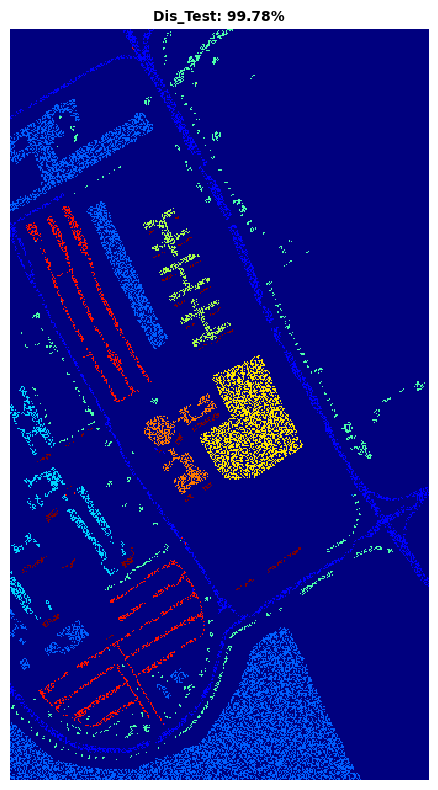

In [43]:
tf.config.run_functions_eagerly(True)
# # Define a list of model names
# model_names = [AttentionGCN, Xtreme_Exception, HybIN, SCSNet, PyFormer]
model_names = [PyFormer]
# Loop over the model names and run train_and_evaluate_model() for each model
history_list = []
for model_name in model_names:
    history = train_and_evaluate_model(model_name, Tr, TrC, Va, VaC, Te, TeC,
                                       adam, CRDHSI, HSID, teRatio, k, WS,
                                       RDHSI, GT, Num_Classes, batch_size,
                                       epochs, val_matrix, VaInd,
                                       test_matrix, TeInd, flattened)
    history_list.append(history)

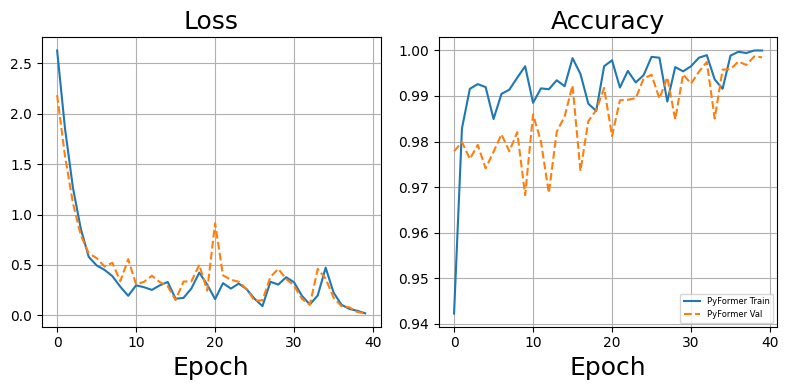

In [44]:
# Plot training and validation loss and accuracy for each model on one graph
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
# colors = ['brown', 'gray', 'blue', 'green', 'purple', 'orange', 'yellow', 'red', 'YlOrBr', 'RdPu', 'YlGn']

for i, history in enumerate(history_list):
    # Plot loss
    axs[0].plot(history.history['loss'], label=f'{model_names[i].__name__} Train')
    axs[0].plot(history.history['val_loss'], label=f'{model_names[i].__name__} Val', linestyle='--')
    # Plot accuracy
    axs[1].plot(history.history['accuracy'], label=f'{model_names[i].__name__} Train')
    axs[1].plot(history.history['val_accuracy'], label=f'{model_names[i].__name__} Val', linestyle='--')
# Add labels and legend
axs[0].set_title('Loss', fontsize=18)
axs[0].set_xlabel('Epoch', fontsize=18)
# axs[0].set_ylabel('Loss', fontsize=18)
# axs[0].legend(fontsize=18)

axs[1].set_title('Accuracy', fontsize=18)
axs[1].set_xlabel('Epoch', fontsize=18)
# axs[1].set_ylabel('Accuracy', fontsize=18)
axs[1].legend(fontsize=6)

# Add grid lines and set background color
axs[0].grid(True)
axs[1].grid(True)
# fig.patch.set_facecolor('#f2f2f2')
plt.tight_layout()
file_name = f"{HSID}_{teRatio}_{k}_{WS}_acc_loss_curve_all_models.png"
plt.savefig(file_name, dpi=500, format='png', bbox_inches='tight', pad_inches=0)